## Домашняя работа

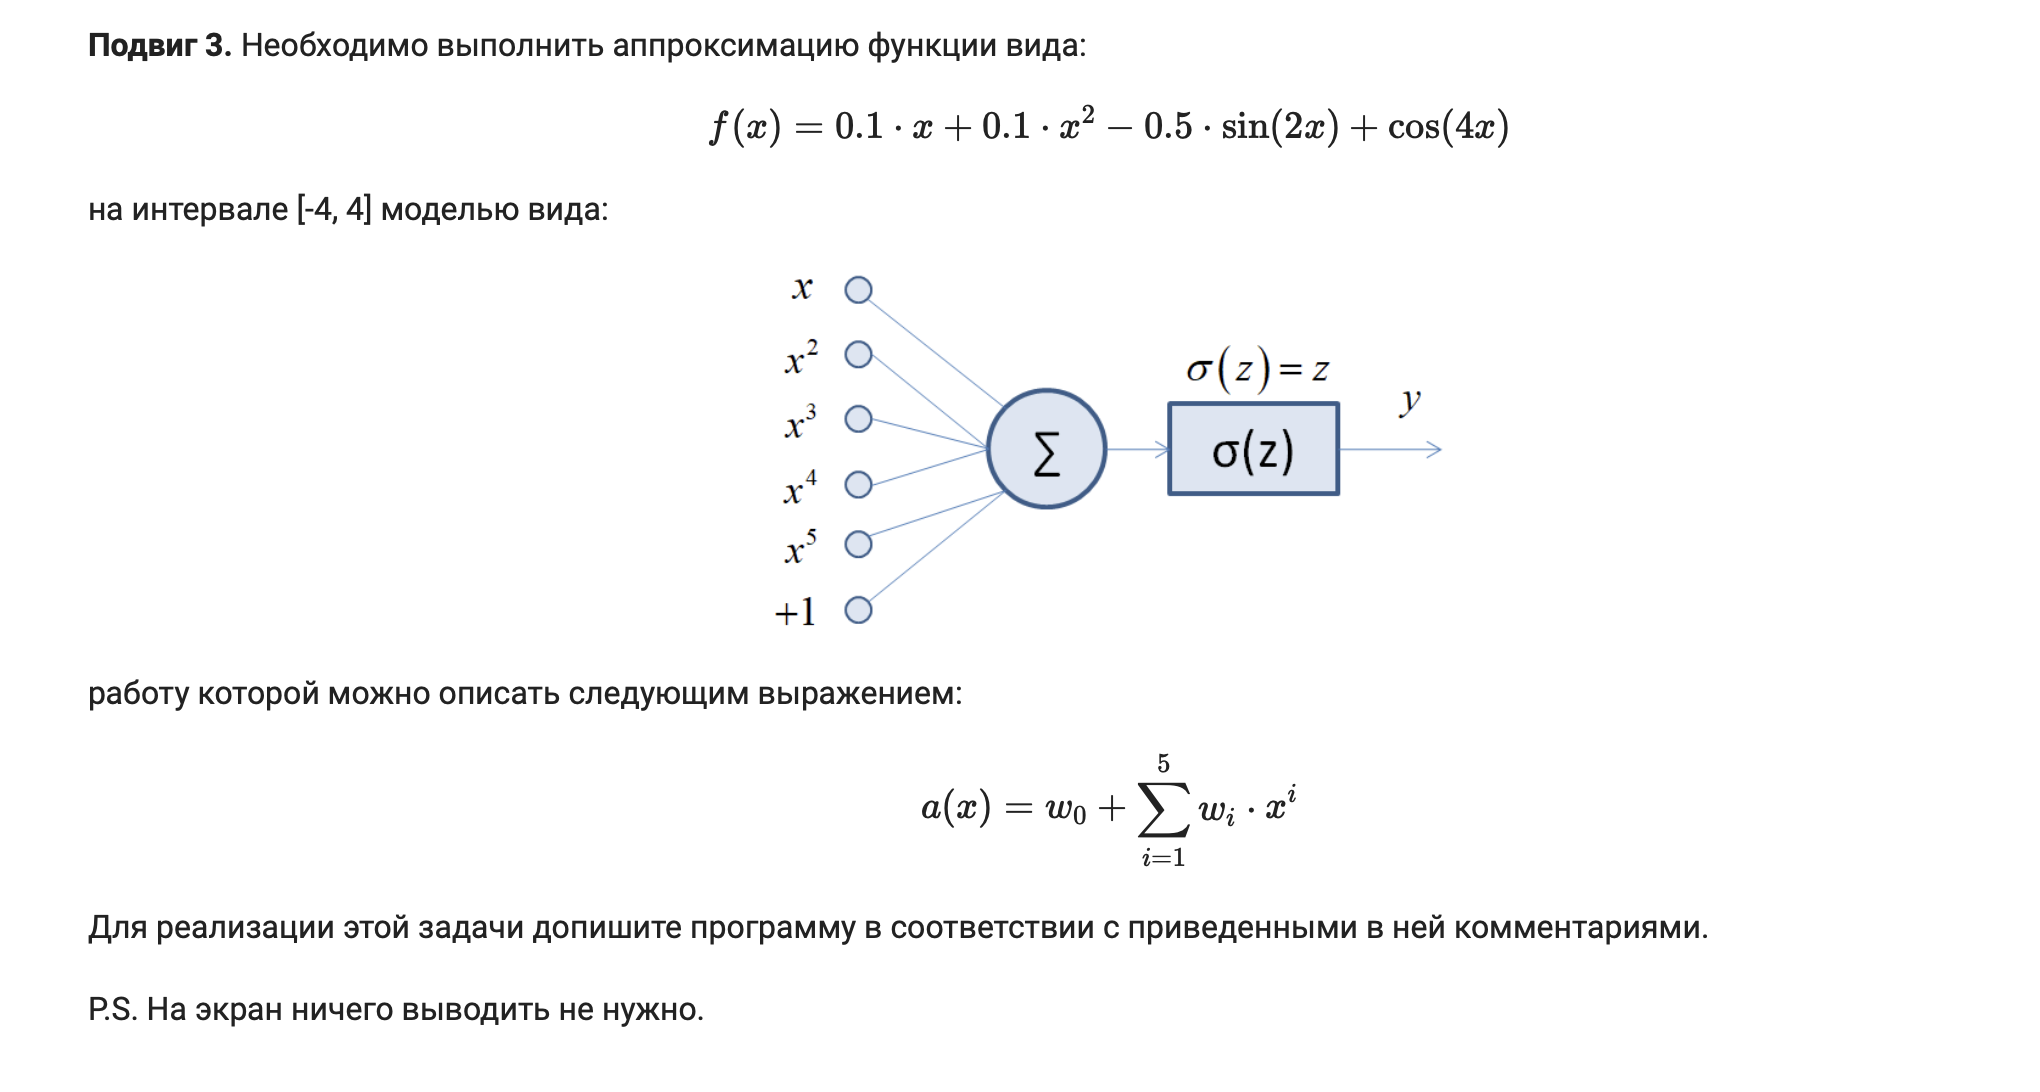

In [4]:
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim

class FuncModel(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.layer = nn.Linear(in_features, 1) # полносвязный слой: число входов in_features, число нейронов 1

    def forward(self, x):
        return self.layer(x)


torch.manual_seed(1)

epochs = 20 # число эпох обучения
batch_size = 8 # размер батча
N = 6 # порядок модели (N-1)

# формирование обучающей выборки (значений функции)
data_x = torch.arange(-4, 4, 0.01)
data_y = 0.1 * data_x + 0.1 * data_x ** 2 - 0.5 * torch.sin(2 * data_x) + torch.cos(4 * data_x)
data_x.unsqueeze_(-1)
X = torch.cat([data_x ** _n for _n in range(N)], dim=1)
ds = data.TensorDataset(X, data_y)

d_train, d_val = data.random_split(ds, [0.8, 0.2]) # разделите выборку ds на две части в пропорции: 80% и 20%
train_data = data.DataLoader(d_train, batch_size=batch_size, shuffle=True)
train_data_val = data.DataLoader(d_val, batch_size=len(d_val), shuffle=False)

model = FuncModel(N)
optimizer = optim.RMSprop(model.parameters(), lr=0.01, weight_decay=10) # создайте оптимизатор RMSprop для модели model с шагом обучения 0.01 и weight_decay=10
loss_func = nn.MSELoss() # сформируйте функцию потерь с помощью класса MSELoss

loss_lst_val = []  # список значений потерь при валидации
loss_lst = []  # список значений потерь при обучении

for _e in range(epochs):
    # переведите модель в режим обучения
    model.train()
    loss_mean = 0
    lm_count = 0

    for x_train, y_train in train_data:
        predict = model(x_train) # вычислите прогноз модели для x_train
        loss = loss_func(predict.squeeze(), y_train) # вычислите потери для predict и y_train

        # выполните один шаг обучения (градиентного спуска)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        lm_count += 1
        loss_mean = 1 / lm_count * loss.item() + (1 - 1 / lm_count) * loss_mean

    # валидация модели
    # переведите модель в режим эксплуатации
    model.eval()
    x_val, y_val = next(iter(train_data_val))

    with torch.no_grad():
        p = model(x_val) # вычислите прогноз модели для x_val
        loss = loss_func(p.squeeze(), y_val) # вычислите потери для p и y_val
        Q_val = loss.item()

    loss_lst.append(loss_mean)
    loss_lst_val.append(Q_val)

# переведите модель в режим эксплуатации
model.eval()
p = model(X) # вычислите прогноз модели по всем данным выборки X
Q =loss_func(p.squeeze(), data_y).item()  # вычислите потери с помощью loss_func для p и data_y; значение Q сохраните в виде вещественного числа
Q

0.6522690057754517

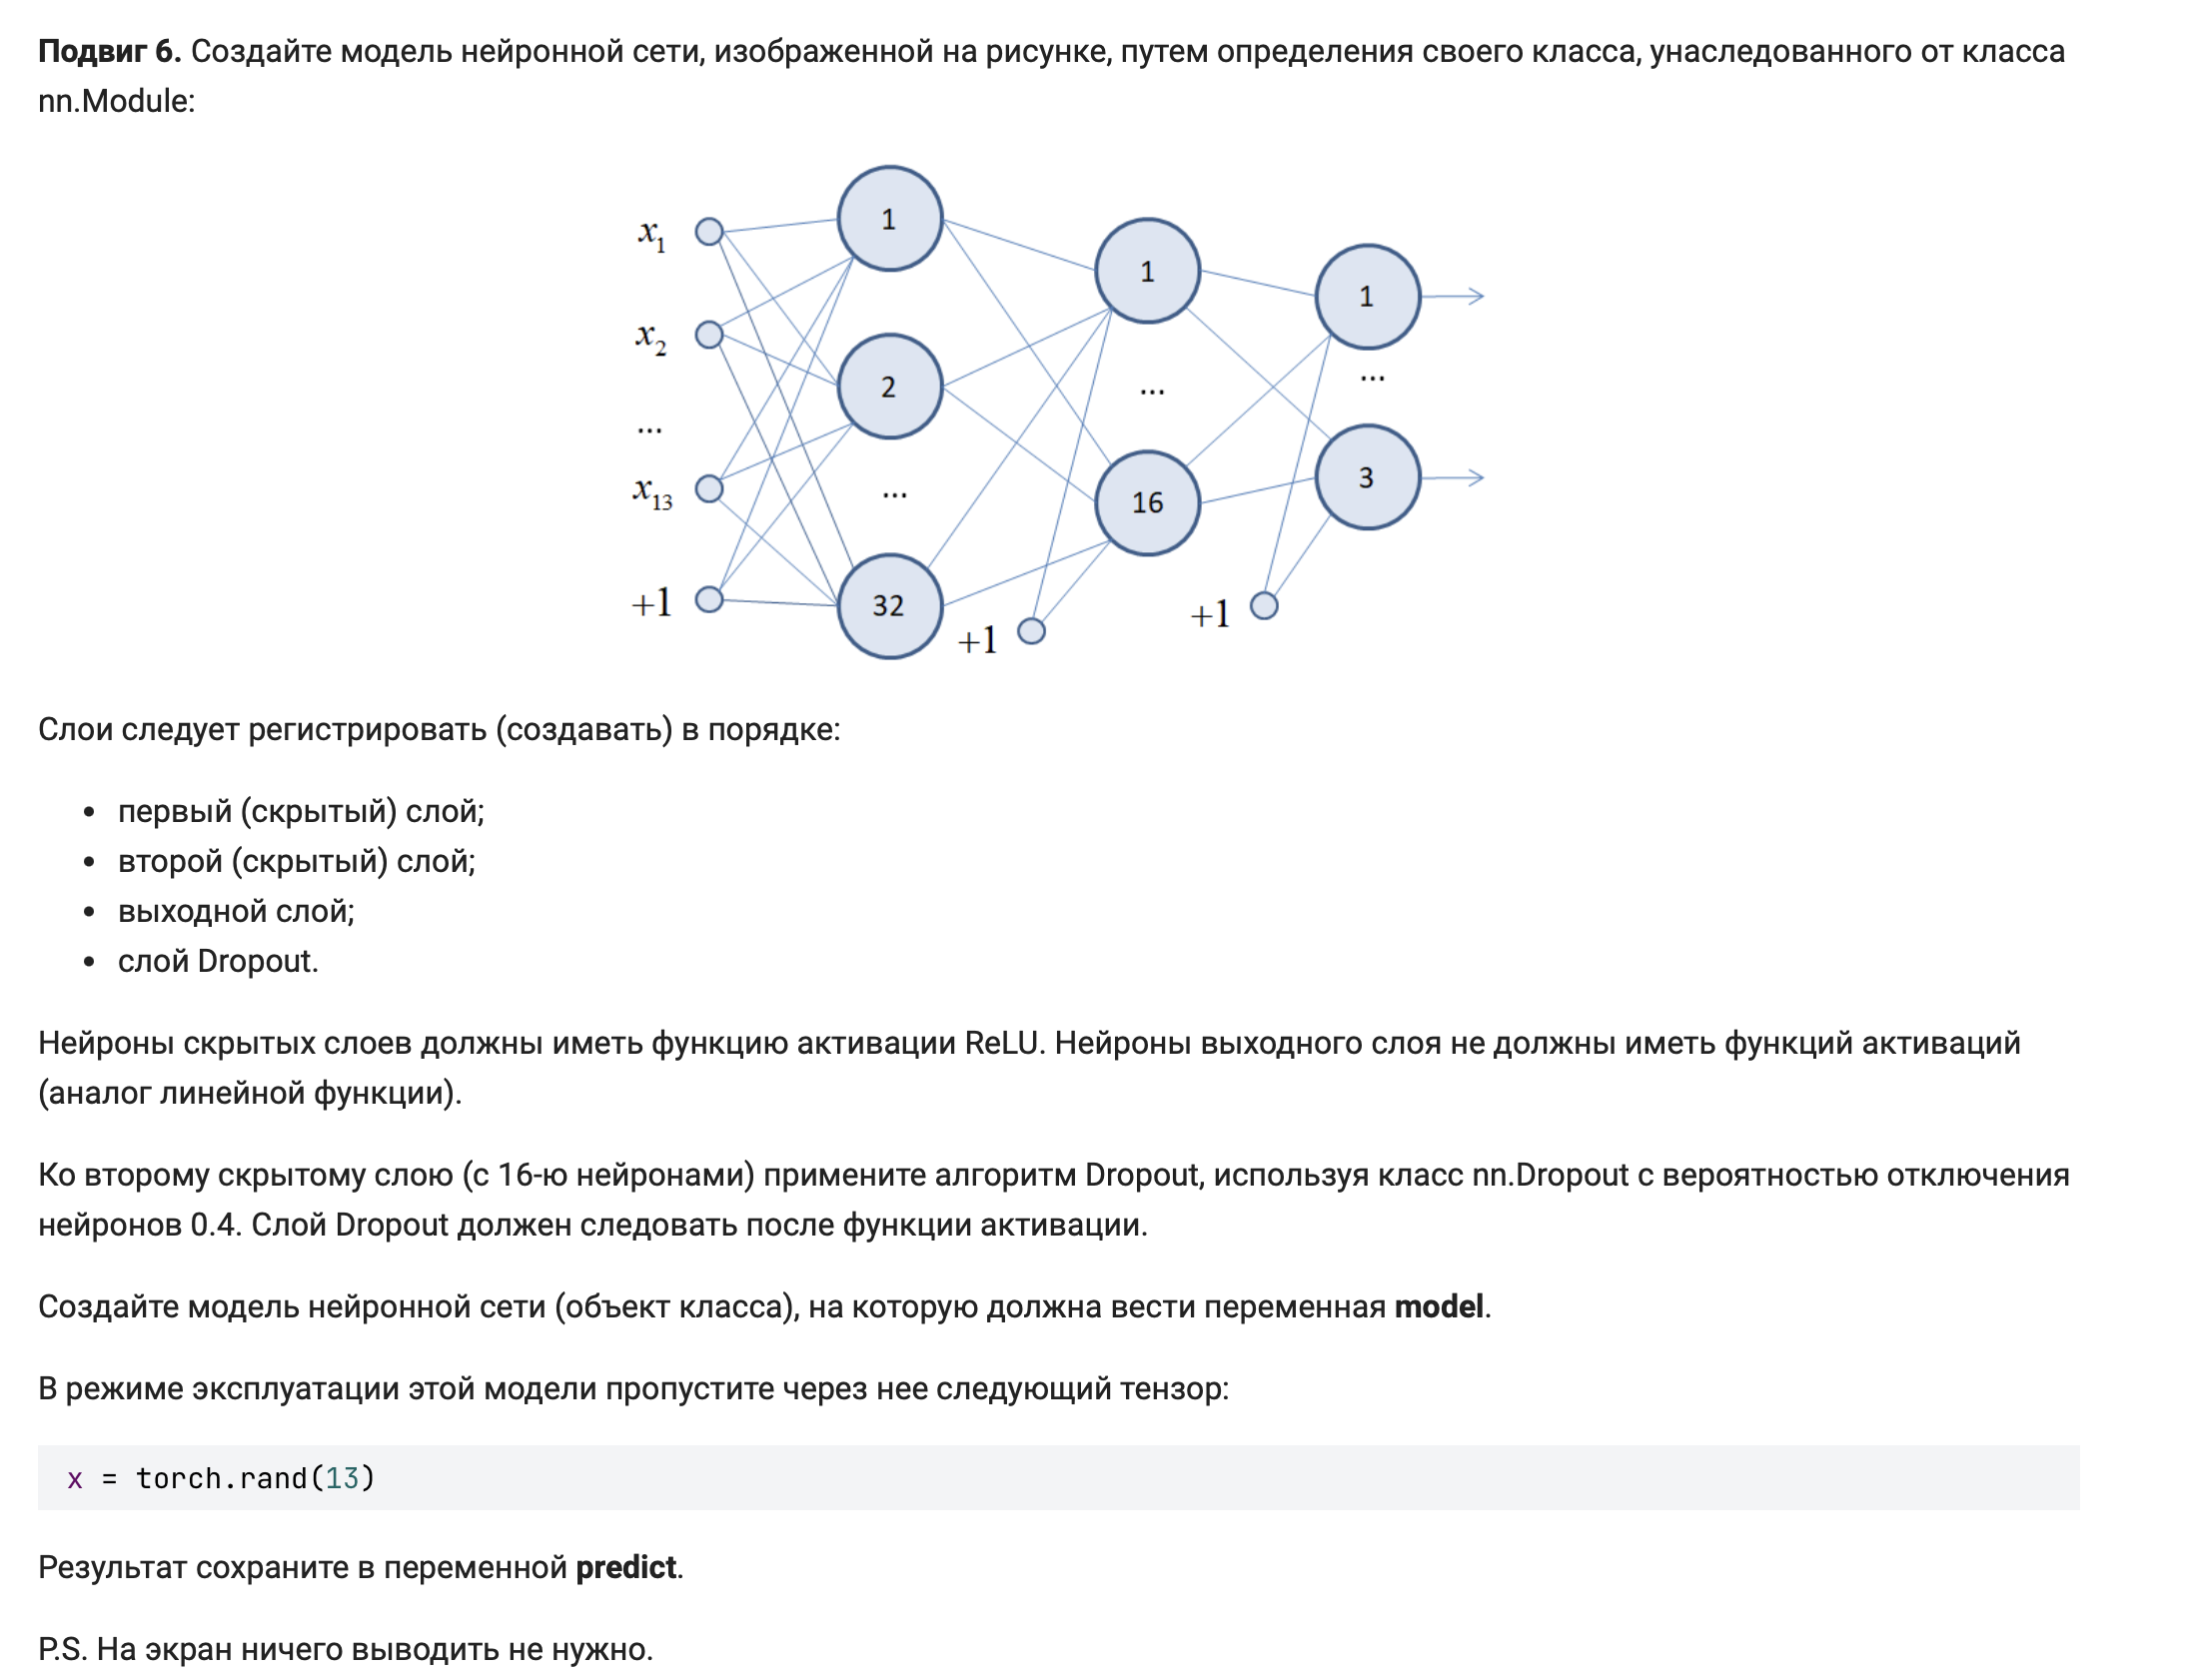

In [7]:
# здесь объявляйте класс модели (обязательно до тензора x)
class Model(nn.Module):
    def __init__(self, inp, hid1, hid2, out, p):
        super().__init__()
        self.l1 = nn.Linear(inp, hid1)
        self.l2 = nn.Linear(hid1, hid2)
        self.l3 = nn.Linear(hid2, out)
        self.dropout = nn.Dropout(p)

    def forward(self, x):
        x = self.l1(x).relu()
        x = self.l2(x).relu()
        x = self.dropout(x)
        x = self.l3(x)

        return x

model = Model(13, 32, 16, 3, 0.4) # здесь создавайте объект модели

x = torch.rand(13)

# здесь продолжайте программу для вычисления predict
predict = model(x)

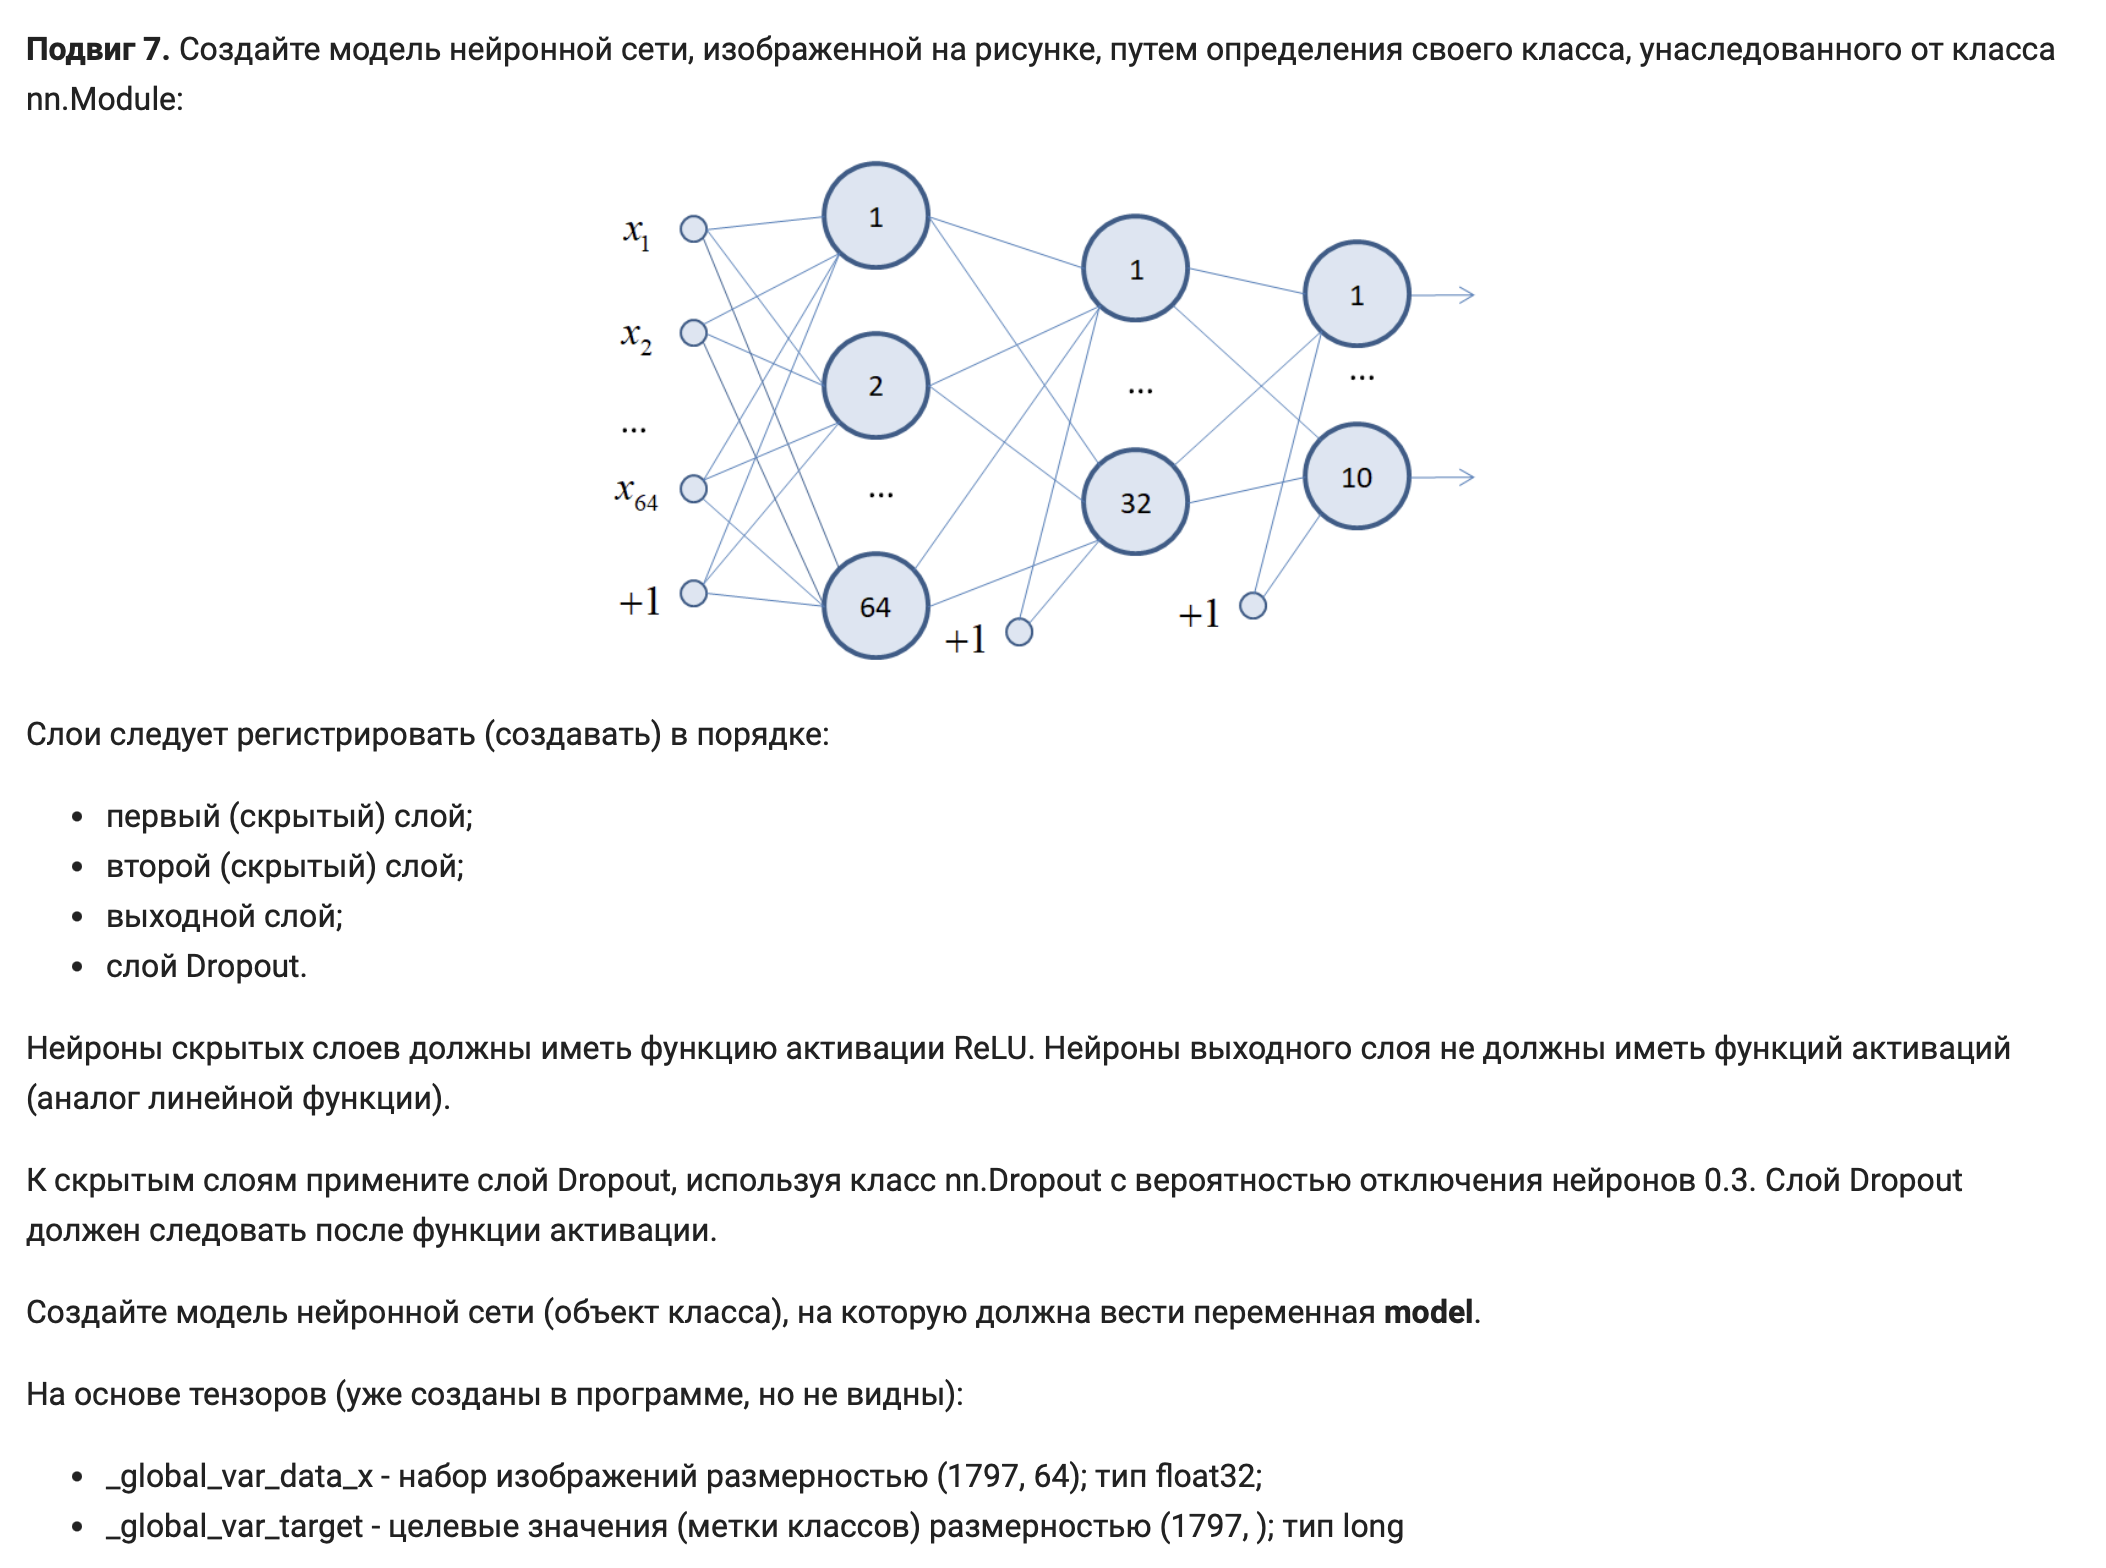
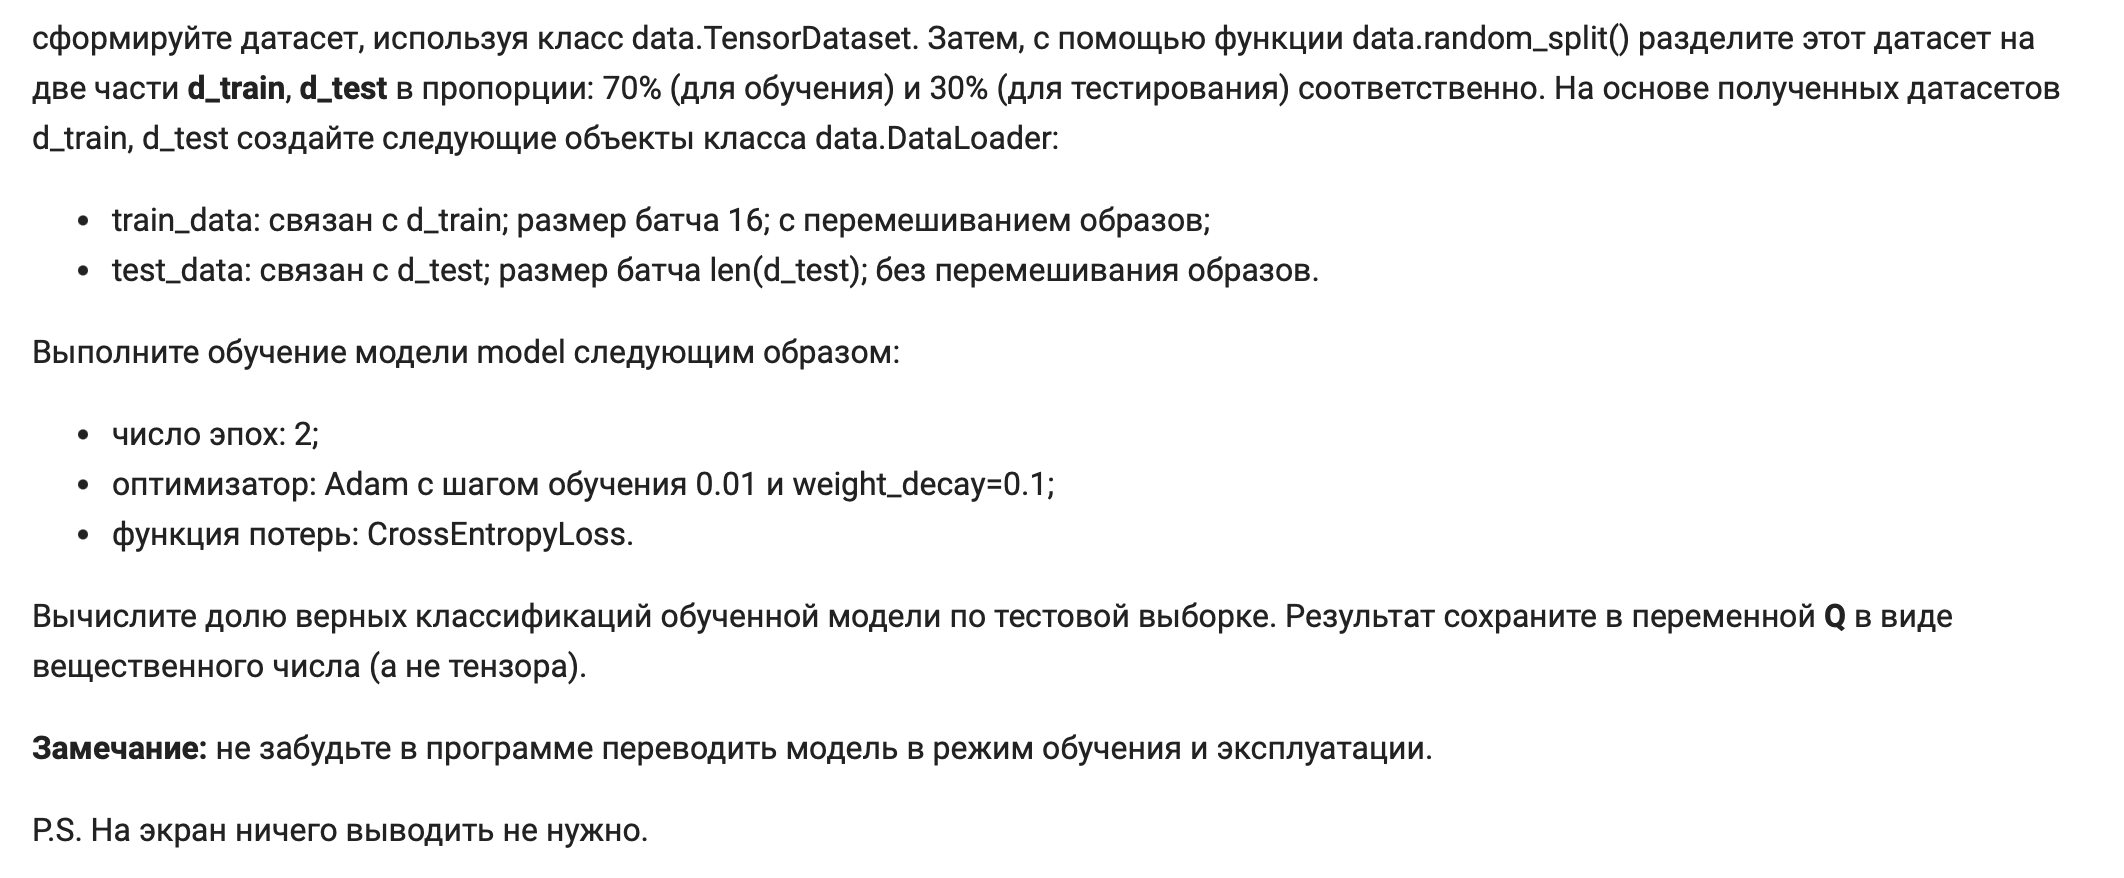

In [22]:
# здесь объявляйте класс модели (обязательно до тензора x)
class Model(nn.Module):
    def __init__(self, inp, hid1, hid2, out, p):
        super().__init__()
        self.l1 = nn.Linear(inp, hid1)
        self.l2 = nn.Linear(hid1, hid2)
        self.l3 = nn.Linear(hid2, out)
        self.dropout = nn.Dropout(p)

    def forward(self, x):
        x = self.l1(x).relu()
        x = self.dropout(x)
        x = self.l2(x).relu()
        x = self.dropout(x)
        x = self.l3(x)

        return x
    
model = Model(64, 64, 32, 10, 0.3)

# для проверки корректности работы
_global_var_data_x = torch.ones(1797, 64).float()
_global_var_target = torch.ones(1797).long()

ds = data.TensorDataset(_global_var_data_x, _global_var_target)
d_train, d_test = data.random_split(ds, [0.7, 0.3])
train_data = data.DataLoader(d_train, batch_size=16, shuffle=True)
test_data = data.DataLoader(d_test, batch_size=len(d_test), shuffle=False)

optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=0.1)
loss_func = nn.CrossEntropyLoss()

model.train()
for i in range(2):
    for x_train, y_train in train_data:
        pred = model(x_train)
        loss = loss_func(pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

model.eval()
with torch.no_grad():
    for x_val, y_val in test_data:
        pred = model(x_val)
        cl_idx = pred.argmax(dim=1)
        Q = (cl_idx == y_val).float().mean().item()
Q

1.0